In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
%pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 41.3 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.


In [ ]:
import numpy as np
import pandas as pd
import wfdb
import os
import ast
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader, random_split, Subset
import torchvision.models as models
from torch import nn
import torch.nn.functional as F
#from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/ECGDataset/ptbxl_database.csv')

In [ ]:
#Import Signals that are contained ONLY in dataframe (i.e. PT-BXL Database)
def getSignal(path):
  signal = []
  onlySignal = []
  res ='records100'
  for directory1 in sorted(os.listdir(path)):
    for directory2 in sorted(os.listdir(path + '/' + directory1)):
      if (df["filename_lr"].isin([(res + '/' + directory1 + '/' + directory2).rsplit('.', 1)[0]]).any().any() and directory2.endswith(".hea")):
        onlySignal, _ = wfdb.rdsamp((path + '/' + directory1 + '/' + directory2).rsplit('.', 1)[0])
        signal.append(onlySignal)
  return signal

In [ ]:
signals = []
path = "/content/drive/MyDrive/ECGDataset/records100"
signals = getSignal(path)

In [ ]:
df['scp_codes'] = df['scp_codes'].apply(ast.literal_eval)
df["Label"] = df['scp_codes'].apply(lambda x: max(x, key=x.get))

In [ ]:
df = df.drop(['ecg_id','patient_id','age','sex','height','weight','nurse',
         'site','device','recording_date','report','heart_axis','infarction_stadium1',
         'infarction_stadium2','validated_by','second_opinion','initial_autogenerated_report',
         'validated_by_human','baseline_drift','static_noise','burst_noise','electrodes_problems',
         'extra_beats', 'pacemaker','strat_fold','filename_lr','filename_hr', 'scp_codes'], axis=1)

df

,Label
0,NORM
1,NORM
2,NORM
3,NORM
4,NORM
...,...
21794,NDT
21795,NORM
21796,ISCAS
21797,NORM


In [ ]:
mapping = {
  "NDT": 2,
  "NST_": 2,
  "DIG": 2,
  "LNGQT": 2,
  "NORM": 0,
  "IMI": 1,
  "ASMI": 1,
  "LVH": 4,
  "LAFB": 3,
  "ISC_": 2,
  "IRBBB": 3,
  "1AVB": 3,
  "IVCD": 3,
  "ISCAL": 2,
  "CRBBB": 3,
  "CLBBB": 3,
  "ILMI": 1,
  "LAO/LAE": 4,
  "AMI": 1,
  "ALMI": 1,
  "ISCIN": 2,
  "INJAS": 1,
  "LMI": 1,
  "ISCIL": 2,
  "LPFB": 3,
  "ISCAS": 2,
  "INJAL": 1,
  "ISCLA": 2,
  "RVH": 4,
  "ANEUR": 2,
  "RAO/RAE": 4,
  "EL": 2,
  "WPW": 3,
  "ILBBB": 3,
  "IPLMI": 1,
  "ISCAN": 2,
  "IPMI": 1,
  "SEHYP": 4,
  "INJIN": 1,
  "INJLA": 1,
  "PMI": 1,
  "3AVB": 3,
  "INJIL": 1,
  "2AVB": 3,
}

df["LabelGrouped"] = df["Label"].map(mapping)
df

,Label,LabelGrouped
0,NORM,0.0
1,NORM,0.0
2,NORM,0.0
3,NORM,0.0
4,NORM,0.0
...,...,...
21794,NDT,2.0
21795,NORM,0.0
21796,ISCAS,2.0
21797,NORM,0.0


In [ ]:
df["Signal"] = signals
df

,Label,LabelGrouped,Signal
0,NORM,0.0,"[[-0.119, -0.055, 0.064, 0.086, -0.091, 0.004,..."
1,NORM,0.0,"[[0.004, 0.138, 0.134, -0.072, -0.065, 0.136, ..."
2,NORM,0.0,"[[-0.029, -0.079, -0.049, 0.054, 0.011, -0.064..."
3,NORM,0.0,"[[-0.054, -0.138, -0.083, 0.096, 0.015, -0.11,..."
4,NORM,0.0,"[[-0.034, -0.574, -0.54, 0.304, 0.253, -0.556,..."
...,...,...,...
21794,NDT,2.0,"[[-0.052, -0.034, 0.018, 0.043, -0.034, -0.008..."
21795,NORM,0.0,"[[-0.05, -0.013, 0.036, 0.031, -0.042, 0.011, ..."
21796,ISCAS,2.0,"[[0.038, 0.024, -0.014, -0.03, 0.026, 0.005, 0..."
21797,NORM,0.0,"[[-0.057, -0.057, 0.0, 0.057, -0.028, -0.028, ..."


In [ ]:
df = df.dropna(ignore_index = True)
df

,Label,LabelGrouped,Signal
0,NORM,0.0,"[[-0.119, -0.055, 0.064, 0.086, -0.091, 0.004,..."
1,NORM,0.0,"[[0.004, 0.138, 0.134, -0.072, -0.065, 0.136, ..."
2,NORM,0.0,"[[-0.029, -0.079, -0.049, 0.054, 0.011, -0.064..."
3,NORM,0.0,"[[-0.054, -0.138, -0.083, 0.096, 0.015, -0.11,..."
4,NORM,0.0,"[[-0.034, -0.574, -0.54, 0.304, 0.253, -0.556,..."
...,...,...,...
21136,NDT,2.0,"[[-0.052, -0.034, 0.018, 0.043, -0.034, -0.008..."
21137,NORM,0.0,"[[-0.05, -0.013, 0.036, 0.031, -0.042, 0.011, ..."
21138,ISCAS,2.0,"[[0.038, 0.024, -0.014, -0.03, 0.026, 0.005, 0..."
21139,NORM,0.0,"[[-0.057, -0.057, 0.0, 0.057, -0.028, -0.028, ..."


Label
NORM       9134
IMI        1677
NDT        1613
ASMI       1457
LVH        1141
LAFB        888
IRBBB       831
CLBBB       527
NST_        502
CRBBB       385
ISC_        356
IVCD        334
ISCAL       333
ILMI        329
1AVB        201
AMI         173
INJAS       147
ALMI        134
ISCAS       118
ISCIN       104
ISCIL        89
LNGQT        80
WPW          74
LAO/LAE      73
LMI          63
ISCLA        52
ILBBB        45
IPLMI        43
INJAL        40
RAO/RAE      34
EL           31
IPMI         28
LPFB         23
ISCAN        20
DIG          20
PMI          10
RVH           9
SEHYP         8
3AVB          4
INJIL         3
INJLA         3
2AVB          3
INJIN         2
Name: count, dtype: int64




Text(0, 0.5, 'Count')

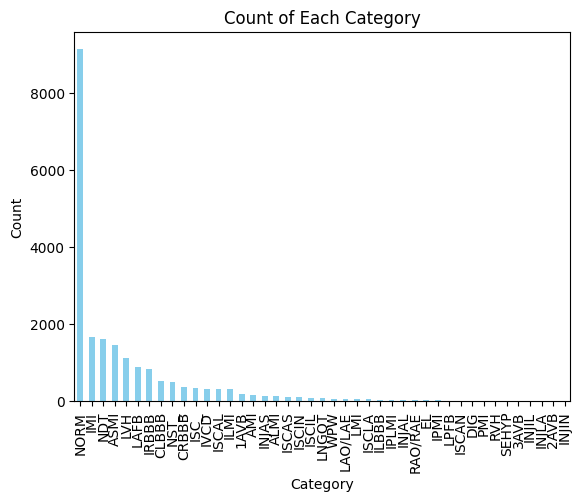

In [ ]:
df["Label"].value_counts().plot(kind='bar', color='skyblue')
print(df["Label"].value_counts())
print( '\n')
plt.title('Count of Each Category')
plt.xlabel('Category')
plt.ylabel('Count')

LabelGrouped
0.0    9134
1.0    4109
2.0    3318
3.0    3315
4.0    1265
Name: count, dtype: int64




Text(0, 0.5, 'Count')

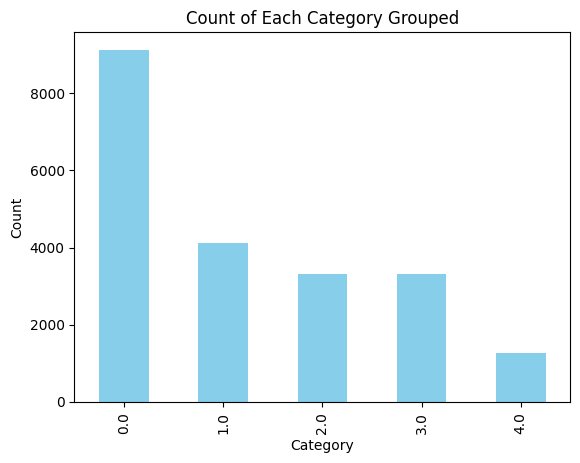

In [ ]:
df["LabelGrouped"].value_counts().plot(kind='bar', color='skyblue')
print(df["LabelGrouped"].value_counts())
print( '\n')
plt.title('Count of Each Category Grouped')
plt.xlabel('Category')
plt.ylabel('Count')

1000


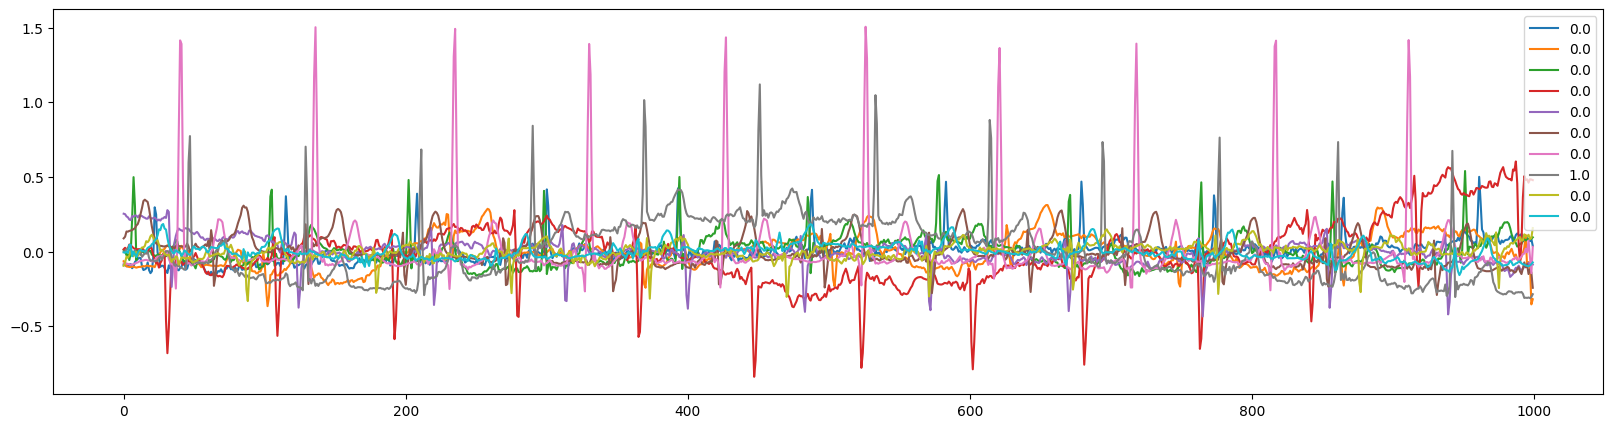

In [ ]:
#Plotting Data in 1 Lead (Lead X) with Label
fig, ax = plt.subplots(figsize=(20, 5))
for i in np.arange(10):
  ax.plot(signals[i][:,4], label = df["LabelGrouped"][i])
ax.legend()
print(len(signals[i][:,4]))

In [ ]:
class ECGDataset(Dataset):
  def __init__(self, signals, labels, train=True):
      self.signals = signals
      self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
      return len(self.labels)

  def __getitem__(self, idx):
    ecg1 = self.signals[idx][:,0]
    ecg2 = self.signals[idx][:,1]
    ecg3 = self.signals[idx][:,2]
    ecg4 = self.signals[idx][:,3]
    ecg5 = self.signals[idx][:,4]
    ecg6 = self.signals[idx][:,5]
    ecg7 = self.signals[idx][:,6]
    ecg8 = self.signals[idx][:,7]
    ecg9 = self.signals[idx][:,8]
    ecg10 = self.signals[idx][:,9]
    ecg11 = self.signals[idx][:,10]
    ecg12 = self.signals[idx][:,11]
    ecg = torch.from_numpy(np.stack((ecg1, ecg2, ecg3, ecg4, ecg5, ecg6, ecg7, ecg8, ecg9, ecg10, ecg11, ecg12))).float()

    labels = self.labels[idx]

    return ecg, labels

dataset = ECGDataset(df["Signal"], df["LabelGrouped"])

splitRatio1 = [int(len(dataset)*0.8 + 1), int(len(dataset)*0.2)]
trainSignals, validationSignals = random_split(dataset, splitRatio1)

validationLoader = DataLoader(validationSignals, batch_size=128, shuffle=True, drop_last=True)

splitRatio2 = [int(len(trainSignals)*0.8 + 1), int(len(trainSignals)*0.2)]
trainSignals, testSignals = random_split(trainSignals, splitRatio2)

trainLoader = DataLoader(trainSignals, batch_size=128, shuffle=True, drop_last=True)
testLoader = DataLoader(testSignals, batch_size=len(testSignals), shuffle=True, drop_last=True)
print(len(testLoader))
print(len(testSignals))
smallDataset = torch.utils.data.Subset(trainSignals, range(20))
smallLoader = DataLoader(smallDataset, batch_size=20, shuffle=True)

1
3382


In [ ]:
class CNN(nn.Module):
  def __init__(self, in_channels, num_classes):
    super(CNN, self).__init__()

    self.features = nn.Sequential(
      nn.Conv1d(12, 32, kernel_size=7, padding=3),
      nn.ReLU(),
      nn.MaxPool1d(2),

      nn.Conv1d(32, 64, kernel_size=5, padding=2),
      nn.ReLU(),
      nn.MaxPool1d(2),

      nn.Conv1d(64, 128, kernel_size=3, padding=1),
      nn.ReLU(),

      nn.AdaptiveAvgPool1d(1)
    )

    self.classifier = nn.Linear(128, num_classes)


  def forward(self, x):
    x = self.features(x)
    x = x.squeeze(-1)
    x = self.classifier(x)
    return x

In [ ]:
model = CNN(in_channels=12, num_classes=5)
#print(model)

In [ ]:
criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
num_epochs = 200

for epoch in range(num_epochs):
  train_loss = 0
  validation_loss = 0
  accuracy_train = 0
  accuracy_validation = 0
  total_train = 0
  total_validation = 0

  print(f'Epoch: {epoch+1}')
  model.train()
  for i, data in enumerate(trainLoader):
    train_signal, train_label = data

    outputs = model(train_signal)
    #print(f"Outputs {outputs}")
    loss = criterion(outputs, train_label)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_loss += loss.item()
    #print(f"Train Loss: {loss.item():.4f}")
    #print(f"Total Train Loss: {train_loss}")
    _, predicted = torch.max(outputs,1)

    accuracy_train += accuracy_score(train_label, predicted, normalize=False)

    total_train += len(train_label)
  #print(f"Train Label {train_label}")
  #print(f"Predicted Values: {predicted}")
  model.eval()

  for i, data in enumerate(validationLoader):
    validation_signal, validation_label = data
    with torch.no_grad():

      outputs = model(validation_signal)
      #print(f"Outputs {outputs}")
      loss = criterion(outputs, validation_label)

      validation_loss += loss.item()
      #print(f"Train Loss: {loss.item():.4f}")
      #print(f"Total Validation Loss: {validation_loss}")
      _, predicted = torch.max(outputs,1)

      accuracy_validation += accuracy_score(validation_label, predicted, normalize=False)

      total_validation += len(validation_label)
  #print(f"Validation Label {validation_label}")
  #print(f"Predicted Values: {predicted}")

  #print(f'Small Accuracy: {accuracy_train/total_train}')
  #print(f'Small Avg. Loss: {train_loss/len(smallLoader)}')
  print(f'Train Accuracy: {accuracy_train/total_train}')
  print(f'Train Avg. Loss: {train_loss/len(trainLoader)}')
  print(f'Validation Accuracy: {accuracy_validation/total_validation}')
  print(f'Validation Avg. Loss: {validation_loss/len(validationLoader)}')

Epoch: 1
Train Accuracy: 0.4466517857142857
Train Avg. Loss: 1.3850448506219046
Validation Accuracy: 0.5222537878787878
Validation Avg. Loss: 1.2310999704129768
Epoch: 2
Train Accuracy: 0.5571428571428572
Train Avg. Loss: 1.1523575374058315
Validation Accuracy: 0.5762310606060606
Validation Avg. Loss: 1.0960805343859124
Epoch: 3
Train Accuracy: 0.606547619047619
Train Avg. Loss: 1.0276951000803993
Validation Accuracy: 0.6221590909090909
Validation Avg. Loss: 0.9822786901936387
Epoch: 4
Train Accuracy: 0.6438988095238095
Train Avg. Loss: 0.9542270683106922
Validation Accuracy: 0.6448863636363636
Validation Avg. Loss: 0.9497189557913578
Epoch: 5
Train Accuracy: 0.6602678571428572
Train Avg. Loss: 0.9125035927409217
Validation Accuracy: 0.6569602272727273
Validation Avg. Loss: 0.8984936042265459
Epoch: 6
Train Accuracy: 0.6713541666666667
Train Avg. Loss: 0.873453984941755
Validation Accuracy: 0.6728219696969697
Validation Avg. Loss: 0.8872959360931859
Epoch: 7
Train Accuracy: 0.6796875
T

In [ ]:
test_correct = 0
total_test = 0

for i, data in enumerate(testLoader):
  test_signal, test_label = data

  with torch.no_grad():
    outputs = model(test_signal)

    #print(f"Test Labels: {testLabel}")
    #print(f"Test Predicted: {predicted}")

    _, predicted = torch.max(outputs,1)
    test_correct += accuracy_score(test_label, predicted, normalize=False)
    total_test += len(test_label)
print(f'Test Accuracy: {test_correct/total_test}')

Test Accuracy: 0.7507392075694855


In [ ]:
print(classification_report(test_label, predicted, target_names = ['NORM', 'MI', 'STTC', 'CD', 'HYP']))

              precision    recall  f1-score   support

        NORM       0.77      0.96      0.85      1452
          MI       0.77      0.67      0.72       635
        STTC       0.68      0.58      0.62       550
          CD       0.73      0.63      0.67       540
         HYP       0.67      0.33      0.44       205

    accuracy                           0.75      3382
   macro avg       0.73      0.63      0.66      3382
weighted avg       0.74      0.75      0.74      3382



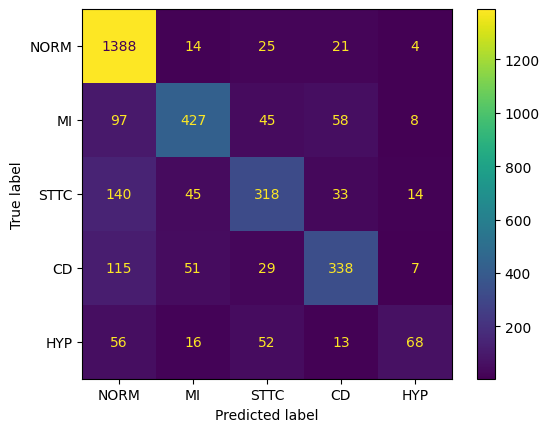

In [ ]:
cm = confusion_matrix(test_label, predicted)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['NORM', 'MI', 'STTC', 'CD', 'HYP']
)

disp.plot()
plt.show()